Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
CSV gerado: /content/gdrive/My Drive/Dataset/Cripto/coins_simple.csv
  Symbol                Date      High       Low      Open     Close
0    BNB 2017-07-26 23:59:59  0.109013  0.099266  0.105893  0.105138
1    BNB 2017-07-27 23:59:59  0.108479  0.100888  0.105108  0.107737
2    BNB 2017-07-28 23:59:59  0.109019  0.101473  0.107632  0.104067
3    BNB 2017-07-29 23:59:59  0.111264  0.101108  0.104782  0.107811
4    BNB 2017-07-30 23:59:59  0.108138  0.103162  0.107935  0.106414
RMSE: 67197.71  MAE: 45373.80  R²: -15.749


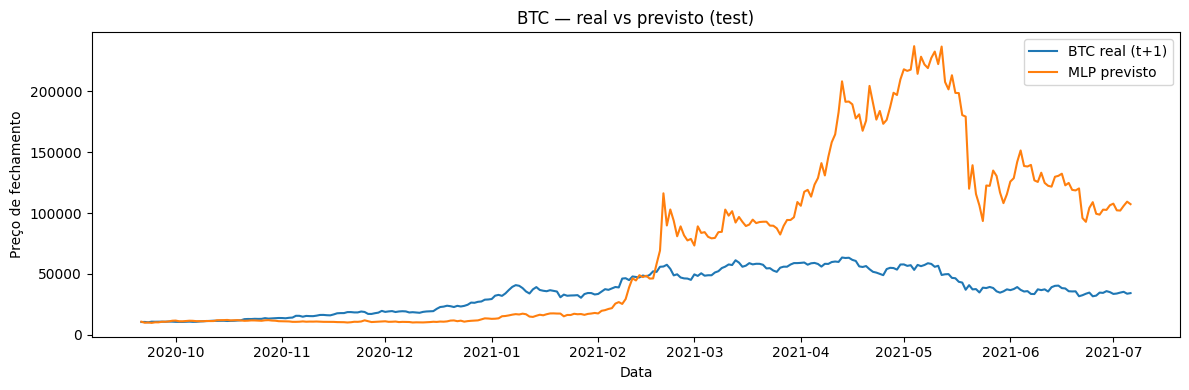

Predições salvas em: /content/gdrive/My Drive/Dataset/Cripto/predicoes_test.csv


In [7]:
# ===============================
# Colab: Previsão simples do BTC
# Estilo do professor (Drive + pandas + sklearn MLP)
# ===============================

# 1) Montar o Google Drive e definir PATH (AJUSTE O PATH!)
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import math

# Monta o Drive
drive.mount('/content/gdrive')

# >>> AJUSTE AQUI <<<
PATH = '/content/gdrive/My Drive/Dataset/Cripto'
# Coloque os 4 arquivos dentro dessa pasta acima, ou mude o PATH para onde eles estão

# Mapeie os arquivos (ajuste os nomes se necessário)
FILES = {
    'BTC': 'coin_Bitcoin.csv',
    'ETH': 'coin_Ethereum.csv',
    'BNB': 'coin_BinanceCoin.csv',
    'LTC': 'coin_Litecoin.csv',
}

# 2) Criar um CSV simples, único, em formato LONGO, com as colunas pedidas
#    (Symbol,Date,High,Low,Open,Close)

def load_one(path, symbol):
    df = pd.read_csv(path)
    # Normaliza nomes (case-insensitive)
    low = {c.lower(): c for c in df.columns}
    req = ['date','open','high','low','close']
    for r in req:
        if r not in low:
            raise ValueError(f"Coluna '{r}' não encontrada em {path}. Colunas: {list(df.columns)}")
    out = df[[low['date'], low['high'], low['low'], low['open'], low['close']]].copy()
    out.columns = ['Date','High','Low','Open','Close']
    out['Symbol'] = symbol
    # Tipos e limpeza
    out['Date'] = pd.to_datetime(out['Date'], errors='coerce')
    out[['High','Low','Open','Close']] = out[['High','Low','Open','Close']].apply(pd.to_numeric, errors='coerce')
    out = out.dropna(subset=['Date','High','Low','Open','Close']).sort_values('Date')
    # Reordena colunas no formato pedido
    out = out[['Symbol','Date','High','Low','Open','Close']]
    return out

long_parts = []
for sym, fname in FILES.items():
    full = os.path.join(PATH, fname)
    part = load_one(full, sym)
    long_parts.append(part)

coins_long = pd.concat(long_parts, ignore_index=True)
coins_long = coins_long.sort_values(['Symbol','Date']).reset_index(drop=True)

# Salva o CSV consolidado no Drive (na MESMA pasta PATH)
OUT_LONG = os.path.join(PATH, 'coins_simple.csv')
coins_long.to_csv(OUT_LONG, index=False)
print('CSV gerado:', OUT_LONG)
print(coins_long.head())

# 3) Preparar dados para treino (pivot -> CLOSE em colunas)
#    Alvo: BTC de t+1. Preditoras: ETH, BNB, LTC (t)
wide = coins_long.pivot(index='Date', columns='Symbol', values='Close').sort_index()
# Garante colunas necessárias
need = ['BTC','ETH','BNB','LTC']
missing = [c for c in need if c not in wide.columns]
if missing:
    raise ValueError('Faltam colunas no pivot: ' + ', '.join(missing))

wide = wide[need].dropna()

# Features (x_t) e alvo (BTC_{t+1})
X = wide[['ETH','BNB','LTC']]
y = wide['BTC'].shift(-1)
mask = ~y.isna()
X, y = X.loc[mask], y.loc[mask]

# Split temporal simples (80/20)
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Escalonamento + MLP básico (sem grid, didático)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

mlp = MLPRegressor(hidden_layer_sizes=(16,8), activation='relu', solver='adam',
                   max_iter=1000, random_state=42)
mlp.fit(X_train_s, y_train)

pred = mlp.predict(X_test_s)

# Métricas simples
rmse = math.sqrt(((y_test - pred)**2).mean())
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)
print(f"RMSE: {rmse:.2f}  MAE: {mae:.2f}  R²: {r2:.3f}")

# 4) Gráfico: real vs previsto
plt.figure(figsize=(12,4))
plt.plot(y_test.index, y_test.values, label='BTC real (t+1)')
plt.plot(y_test.index, pred, label='MLP previsto')
plt.legend()
plt.title('BTC — real vs previsto (test)')
plt.xlabel('Data')
plt.ylabel('Preço de fechamento')
plt.tight_layout()
plt.show()

# 5) Exportar previsões para novo CSV na mesma pasta PATH
pred_df = pd.DataFrame({
    'Date': y_test.index,
    'y_true': y_test.values,
    'y_pred_mlp': pred
})
OUT_PRED = os.path.join(PATH, 'predicoes_test.csv')
pred_df.to_csv(OUT_PRED, index=False)
print('Predições salvas em:', OUT_PRED)
